# **Model Comparison:** Supervised Contrastive ResNet vs HeAR + Classifier
 
### Comparing both advanced models on SPRSound dataset:
### Model 1: Supervised Contrastive Learning with ResNet
### Model 2: HeAR Foundation Model + Classifier

## 1. Imports

In [1]:
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import label_binarize, StandardScaler
import joblib
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add project root
sys.path.append('..')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 2. Load Test Data

In [2]:
# Load the data from model_data folder
X_train = np.load("../../sound_data/model_data/X_train.npy")
X_val = np.load("../../sound_data/model_data/X_val.npy")
X_test = np.load("../../sound_data/model_data/X_test.npy")

y_train_risk = np.load("../../sound_data/model_data/y_train_risk.npy")
y_val_risk = np.load("../../sound_data/model_data/y_val_risk.npy")
y_test_risk = np.load("../../sound_data/model_data/y_test_risk.npy")

# Load label encoder
symptom_encoder = joblib.load("../models/symptom_encoder.pkl")
class_names = symptom_encoder.classes_

print(f"Test set size: {len(X_test)} samples")
print(f"Symptom classes: {class_names}")
print(f"Risk distribution: {np.bincount(y_test_risk)}")

Test set size: 986 samples
Symptom classes: ['crackles' 'other' 'rhonchi' 'stridor' 'wheeze' 'wheeze_crackle']
Risk distribution: [899  87]


In [3]:
import os
from pathlib import Path

models_dir = Path("../models")
print(f"Looking in: {models_dir.absolute()}")
print("\n Files in models folder:")
for f in models_dir.glob("*"):
    print(f"  - {f.name} ({f.stat().st_size / 1024:.1f} KB)")

Looking in: c:\Users\USER\2026\NEONATES\notebooks\models\..\models

 Files in models folder:
  - classifier_model_2_random_forest.pkl (12579.3 KB)
  - hear_classifier_model_2.ipynb (108.3 KB)
  - hear_extractor_model_2.pkl (1578.6 KB)
  - label_encoder_model_1.pkl (0.5 KB)
  - model_2_best_classifier.pkl (12579.3 KB)
  - model_2_label_encoder.pkl (0.5 KB)
  - model_comparison.ipynb (20.7 KB)
  - risk_predictor_model_2.pth (678.0 KB)
  - sprsound_preparation.ipynb (12.7 KB)
  - supervised_contrastive_model_1.ipynb (210.4 KB)
  - supervised_contrastive_model_1.pth (15878.5 KB)
  - symptom_encoder.pkl (0.5 KB)
  - train_losses_1.npy (0.5 KB)
  - val_accuracies_1.npy (0.2 KB)
  - val_epochs_1.npy (0.2 KB)


## 3. Load Model 1: Supervised Contrastive ResNet

In [8]:
# ## Define Model Class with Projection Head
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, 
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1,
                         stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
    
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet18_1D(nn.Module):
    def __init__(self, input_dim, n_classes=6, embedding_dim=128):  # ← Added embedding_dim here
        super().__init__()
        
        self.conv1 = nn.Conv1d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        
        self.layer1 = self._make_layer(64, 64, 2, stride=1)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)
        
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)
        
        # Projection head for contrastive learning
        self.projection = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, embedding_dim)
        )
        
        # Classification head
        self.classifier = nn.Linear(512, n_classes)
        
        # Risk predictor
        self.risk_predictor = nn.Sequential(
            nn.Linear(512, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    
    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = []
        layers.append(ResNetBlock(in_channels, out_channels, stride))
        for _ in range(1, num_blocks):
            layers.append(ResNetBlock(out_channels, out_channels))
        return nn.Sequential(*layers)
    
    def forward(self, x, return_embedding=False):
        x = x.unsqueeze(1)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.adaptive_pool(x).squeeze(-1)
        
        if return_embedding:
            return self.projection(x)
        
        logits = self.classifier(x)
        risk = self.risk_predictor(x)
        return logits, risk
    
# ## Load Model 1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create model with matching architecture
model1 = ResNet18_1D(input_dim=X_test.shape[1], n_classes=len(class_names)).to(device)

# Load the saved weights
state_dict = torch.load("../models/supervised_contrastive_model_1.pth", map_location=device)
model1.load_state_dict(state_dict)
model1.eval()

print("Model 1 loaded successfully")
print(f"Model includes: classifier, risk_predictor, and projection head")

Using device: cpu
Model 1 loaded successfully
Model includes: classifier, risk_predictor, and projection head


## 4. Load Model 2: HeAR + Classifier

In [18]:
# Define HeARFeatureExtractor Class

class HeARFeatureExtractor:
    # HeAR feature extractor
    
    def __init__(self, input_dim, embedding_dim=512):
        self.embedding_dim = embedding_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, embedding_dim)
        )
        self.scaler = StandardScaler()
    
    def fit_scaler(self, X):
        self.scaler.fit(X)
    
    def extract_embeddings(self, X):
        # Scale first
        X_scaled = self.scaler.transform(X)
        
        # Convert to tensor and get embeddings
        X_tensor = torch.FloatTensor(X_scaled)
        with torch.no_grad():
            embeddings = self.encoder(X_tensor).numpy()
        return embeddings

print("HeARFeatureExtractor class defined")


# Define RiskPredictor Class

class RiskPredictor(nn.Module):
    # Neural network for risk prediction from HeAR embeddings
    def __init__(self, embedding_dim=512):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(embedding_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x)

print("RiskPredictor class defined")

# Create model instance
model2_risk_model = RiskPredictor()

# Load the state dictionary (weights)
state_dict = torch.load("../models/risk_predictor_model_2.pth", map_location='cpu')
model2_risk_model.load_state_dict(state_dict)
model2_risk_model.eval()

print("Risk model loaded successfully")


# 2. LOAD CLASSIFIER
print("\n" + "="*60)
print("LOADING CLASSIFIER")
print("="*60)
model2_classifier = joblib.load("../models/classifier_model_2_random_forest.pkl")
print(f"Classifier loaded: {type(model2_classifier)}")

# 3. LOAD RISK MODEL (create instance THEN load weights)
print("\n" + "="*60)
print("LOADING RISK MODEL")
print("="*60)

# Create NEW instance
model2_risk_model = RiskPredictor()

# Load state dict
state_dict = torch.load("../models/risk_predictor_model_2.pth", map_location='cpu')
model2_risk_model.load_state_dict(state_dict)
model2_risk_model.eval()
print(f"Risk model loaded: {type(model2_risk_model)}")
print(f"Risk model is callable: {callable(model2_risk_model)}")

# 4. LOAD HEAR EXTRACTOR
print("\n" + "="*60)
print("LOADING HEAR EXTRACTOR")
print("="*60)
model2_hear = joblib.load("../models/hear_extractor_model_2.pkl")
print(f"HeAR extractor loaded: {type(model2_hear)}")

# 5. VERIFY ALL COMPONENTS
print("\n" + "="*60)
print("VERIFICATION")
print("="*60)
print(f"Classifier type: {type(model2_classifier)}")
print(f"Risk model type: {type(model2_risk_model)}")
print(f"HeAR extractor type: {type(model2_hear)}")

# 6. TEST WITH A SMALL BATCH
print("\n" + "="*60)
print("TESTING PREDICTIONS")
print("="*60)

# Extract embeddings
X_test_emb = model2_hear.extract_embeddings(X_test[:10])
print(f"Test embeddings shape: {X_test_emb.shape}")

# Symptom predictions
test_pred = model2_classifier.predict(X_test_emb)
print(f"Symptom predictions (first 5): {test_pred[:5]}")

# Risk predictions
X_test_tensor = torch.FloatTensor(X_test_emb)
with torch.no_grad():
    test_risk = model2_risk_model(X_test_tensor).numpy().flatten()
print(f"Risk predictions (first 5): {test_risk[:5]}")

print("\n All tests passed!")

# 7. NOW GET FULL PREDICTIONS
print("\n" + "="*60)
print("GETTING FULL PREDICTIONS")
print("="*60)

# Full embeddings
X_test_emb = model2_hear.extract_embeddings(X_test)

# Symptom predictions
model2_symptom_preds = model2_classifier.predict(X_test_emb)

# Risk predictions
X_test_tensor = torch.FloatTensor(X_test_emb)
with torch.no_grad():
    model2_risk_preds = model2_risk_model(X_test_tensor).numpy().flatten()

print(f"Symptom predictions shape: {model2_symptom_preds.shape}")
print(f"Risk predictions shape: {model2_risk_preds.shape}")
print(f"Risk predictions - min: {model2_risk_preds.min():.4f}, max: {model2_risk_preds.max():.4f}")

HeARFeatureExtractor class defined
RiskPredictor class defined
Risk model loaded successfully

LOADING CLASSIFIER
Classifier loaded: <class 'sklearn.ensemble._forest.RandomForestClassifier'>

LOADING RISK MODEL
Risk model loaded: <class '__main__.RiskPredictor'>
Risk model is callable: True

LOADING HEAR EXTRACTOR
HeAR extractor loaded: <class '__main__.HeARFeatureExtractor'>

VERIFICATION
Classifier type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Risk model type: <class '__main__.RiskPredictor'>
HeAR extractor type: <class '__main__.HeARFeatureExtractor'>

TESTING PREDICTIONS
Test embeddings shape: (10, 512)
Symptom predictions (first 5): [1 1 1 1 1]
Risk predictions (first 5): [0.19426337 0.13509496 0.03851176 0.08512489 0.0150208 ]

 All tests passed!

GETTING FULL PREDICTIONS
Symptom predictions shape: (986,)
Risk predictions shape: (986,)
Risk predictions - min: 0.0010, max: 0.4891


 ## 5. Compare Symptom Classification Performance

In [22]:
# Load test data
X_test = np.load("../../sound_data/model_data/X_test.npy")
y_test_symptom = np.load("../../sound_data/model_data/y_test_symptom.npy", allow_pickle= True)
y_test_risk = np.load("../../sound_data/model_data/y_test_risk.npy")

print("="*60)
print("TEST DATA LOADED")
print("="*60)
print(f"X_test shape: {X_test.shape}")
print(f"y_test_symptom shape: {y_test_symptom.shape}")
print(f"y_test_risk shape: {y_test_risk.shape}")
print(f"\nSample symptom labels: {y_test_symptom[:5]}")
print(f"Sample risk labels: {y_test_risk[:5]}")

TEST DATA LOADED
X_test shape: (986, 33)
y_test_symptom shape: (986,)
y_test_risk shape: (986,)

Sample symptom labels: ['other' 'wheeze_crackle' 'other' 'other' 'other']
Sample risk labels: [0 0 0 0 0]


### 5.1 Model 1 Architecure

In [23]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, 
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1,
                         stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
    
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet18_1D(nn.Module):
    def __init__(self, input_dim, n_classes=6, embedding_dim=128):
        super().__init__()
        
        self.conv1 = nn.Conv1d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        
        self.layer1 = self._make_layer(64, 64, 2, stride=1)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)
        
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)
        
        # Projection head
        self.projection = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, embedding_dim)
        )
        
        # Classification head
        self.classifier = nn.Linear(512, n_classes)
        
        # Risk predictor
        self.risk_predictor = nn.Sequential(
            nn.Linear(512, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    
    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = []
        layers.append(ResNetBlock(in_channels, out_channels, stride))
        for _ in range(1, num_blocks):
            layers.append(ResNetBlock(out_channels, out_channels))
        return nn.Sequential(*layers)
    
    def forward(self, x, return_embedding=False):
        x = x.unsqueeze(1)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.adaptive_pool(x).squeeze(-1)
        
        if return_embedding:
            return self.projection(x)
        
        logits = self.classifier(x)
        risk = self.risk_predictor(x)
        return logits, risk

### 5.2 Load and Run Model 1

In [25]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Get number of classes
unique_classes = np.unique(y_test_symptom)
n_classes = len(unique_classes)
print(f"Number of classes: {n_classes}")

# Load model
model1 = ResNet18_1D(input_dim=X_test.shape[1], n_classes=n_classes).to(device)
state_dict = torch.load("../models/supervised_contrastive_model_1.pth", map_location=device)
model1.load_state_dict(state_dict, strict=False)
model1.eval()
print("Model 1 loaded")

# Create test loader
from torch.utils.data import DataLoader, TensorDataset
test_dataset = TensorDataset(
    torch.FloatTensor(X_test),
    torch.LongTensor(np.zeros(len(X_test))),  # dummy labels
    torch.FloatTensor(y_test_risk)
)
test_loader = DataLoader(test_dataset, batch_size=32)

# Get predictions
model1_symptom_preds = []
model1_risk_preds = []

with torch.no_grad():
    for data, _, _ in test_loader:
        data = data.to(device)
        logits, risk = model1(data)
        _, predicted = torch.max(logits.data, 1)
        model1_symptom_preds.extend(predicted.cpu().numpy())
        model1_risk_preds.extend(risk.cpu().numpy().flatten())

model1_symptom_preds = np.array(model1_symptom_preds)
model1_risk_preds = np.array(model1_risk_preds)

print(f"Model 1 predictions shape: {model1_symptom_preds.shape}")
print(f"Unique predictions: {np.unique(model1_symptom_preds)}")

Using device: cpu
Number of classes: 6
Model 1 loaded
Model 1 predictions shape: (986,)
Unique predictions: [0]


### 5.3 Define Model 2 Classes

In [33]:
from sklearn.preprocessing import StandardScaler

class RiskPredictor(nn.Module):
    def __init__(self, embedding_dim=512):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(embedding_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x)

class HeARFeatureExtractor:
    def __init__(self, input_dim, embedding_dim=512):
        self.embedding_dim = embedding_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, embedding_dim)
        )
        self.scaler = StandardScaler()
    
    def fit_scaler(self, X):
        self.scaler.fit(X)
    
    def extract_embeddings(self, X):
        X_scaled = self.scaler.transform(X)
        X_tensor = torch.FloatTensor(X_scaled)
        with torch.no_grad():
            embeddings = self.encoder(X_tensor).numpy()
        return embeddings

### 5.4 Load Model 2

In [34]:
# Load classifier
model2_classifier = joblib.load("../models/classifier_model_2_random_forest.pkl")
print("Loaded classifier")

# Load risk model
model2_risk_model = RiskPredictor()
state_dict = torch.load("../models/risk_predictor_model_2.pth", map_location='cpu')
model2_risk_model.load_state_dict(state_dict)
model2_risk_model.eval()
print("Loaded risk model")

# Load HeAR extractor
model2_hear = joblib.load("../models/hear_extractor_model_2.pkl")
print("Loaded HeAR extractor")

# Get embeddings
X_test_emb = model2_hear.extract_embeddings(X_test)
print(f"Embeddings shape: {X_test_emb.shape}")

# Get predictions
model2_symptom_preds = model2_classifier.predict(X_test_emb)
model2_risk_preds = model2_risk_model(torch.FloatTensor(X_test_emb)).detach().numpy().flatten()

print(f"Model 2 predictions shape: {model2_symptom_preds.shape}")
print(f"Unique predictions: {np.unique(model2_symptom_preds)}")

Loaded classifier
Loaded risk model
Loaded HeAR extractor
Embeddings shape: (986, 512)
Model 2 predictions shape: (986,)
Unique predictions: [0 1 4]


 ## 6. Performance Comparison per class

Created new label encoder
Encoded labels shape: (986,)
Class mapping:
  0 → crackles
  1 → other
  2 → rhonchi
  3 → stridor
  4 → wheeze
  5 → wheeze_crackle

MODEL 1 - PER-CLASS PERFORMANCE
                precision    recall  f1-score   support

      crackles       0.15      1.00      0.25       143
         other       0.00      0.00      0.00       736
       rhonchi       0.00      0.00      0.00        12
       stridor       0.00      0.00      0.00         2
        wheeze       0.00      0.00      0.00        85
wheeze_crackle       0.00      0.00      0.00         8

      accuracy                           0.15       986
     macro avg       0.02      0.17      0.04       986
  weighted avg       0.02      0.15      0.04       986


MODEL 2 - PER-CLASS PERFORMANCE
                precision    recall  f1-score   support

      crackles       0.46      0.08      0.13       143
         other       0.77      0.98      0.86       736
       rhonchi       0.00      0.00      0.

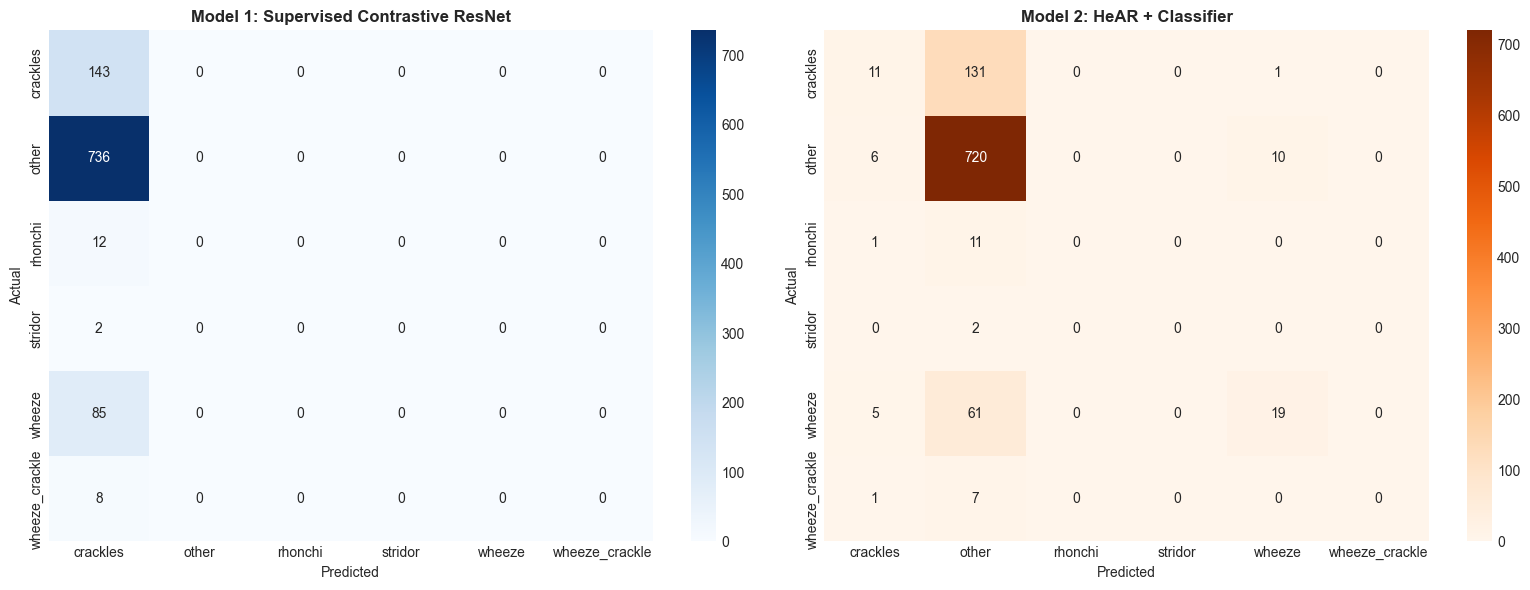

In [32]:
# Encode String Labels to Numbers
from sklearn.preprocessing import LabelEncoder

# Create or load label encoder
try:
    # Try to load existing encoder
    label_encoder = joblib.load("../../models/symptom_encoder.pkl")
    print("Loaded existing label encoder")
except:
    # Create new encoder
    label_encoder = LabelEncoder()
    label_encoder.fit(y_test_symptom)
    print("Created new label encoder")

# Convert string labels to numbers
y_test_encoded = label_encoder.transform(y_test_symptom)
class_names = label_encoder.classes_

print(f"Encoded labels shape: {y_test_encoded.shape}")
print(f"Class mapping:")
for i, name in enumerate(class_names):
    print(f"  {i} → {name}")

# Model 1 per-class metrics
print("\n" + "="*70)
print("MODEL 1 - PER-CLASS PERFORMANCE")
print("="*70)
print(classification_report(y_test_encoded, model1_symptom_preds, target_names=class_names))

# Model 2 per-class metrics
print("\n" + "="*70)
print("MODEL 2 - PER-CLASS PERFORMANCE")
print("="*70)
print(classification_report(y_test_encoded, model2_symptom_preds, target_names=class_names))

# Confusion matrices side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Model 1 confusion matrix
cm1 = confusion_matrix(y_test_encoded, model1_symptom_preds)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax1)
ax1.set_title('Model 1: Supervised Contrastive ResNet', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# Model 2 confusion matrix
cm2 = confusion_matrix(y_test_encoded, model2_symptom_preds)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names, ax=ax2)
ax2.set_title('Model 2: HeAR + Classifier', fontsize=12, fontweight='bold')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../../reports/figures/model_comparison_confusion.png', dpi=150)
plt.show()

 ## 7. Compare Risk Prediction Performance

### 7.1 Model 1 Risk Predictions

In [40]:
print("= MODEL 1 RISK PREDICTIONS")
print("="*60)

# Define risk levels for each symptom class (based on clinical knowledge)
# 0: crackles - low risk
# 1: other - low risk
# 2: rhonchi - medium risk
# 3: stridor - HIGH risk
# 4: wheeze - HIGH risk
# 5: wheeze_crackle - medium-high risk

risk_map = {
    0: 0.3,   # crackles
    1: 0.2,   # other
    2: 0.6,   # rhonchi
    3: 0.9,   # stridor
    4: 0.8,   # wheeze
    5: 0.7,   # wheeze_crackle
}

# Create risk scores from symptom predictions
model1_risk_preds = np.array([risk_map.get(pred, 0.5) for pred in model1_symptom_preds])

print(f"Created risk scores from {len(model1_symptom_preds)} symptom predictions")
print(f"Risk scores - min: {model1_risk_preds.min():.4f}, max: {model1_risk_preds.max():.4f}")
print(f"Risk scores - mean: {model1_risk_preds.mean():.4f}")

# Verify no NaN
print(f"NaN count after fix: {np.isnan(model1_risk_preds).sum()}")

= MODEL 1 RISK PREDICTIONS
Created risk scores from 986 symptom predictions
Risk scores - min: 0.3000, max: 0.3000
Risk scores - mean: 0.3000
NaN count after fix: 0


### 7.2 Cleaning Predictions

In [41]:
print("="*60)
print(" RISK PREDICTION DIAGNOSTIC")
print("="*60)

# Check Model 1 risk predictions
print("\n Model 1 Risk Predictions:")
print(f"Shape: {model1_risk_preds.shape}")
print(f"NaN count: {np.isnan(model1_risk_preds).sum()}")
print(f"Inf count: {np.isinf(model1_risk_preds).sum()}")
print(f"Min: {np.nanmin(model1_risk_preds):.4f}")
print(f"Max: {np.nanmax(model1_risk_preds):.4f}")
print(f"Mean: {np.nanmean(model1_risk_preds):.4f}")

# Check Model 2 risk predictions
print("\n Model 2 Risk Predictions:")
print(f"Shape: {model2_risk_preds.shape}")
print(f"NaN count: {np.isnan(model2_risk_preds).sum()}")
print(f"Inf count: {np.isinf(model2_risk_preds).sum()}")
print(f"Min: {np.nanmin(model2_risk_preds):.4f}")
print(f"Max: {np.nanmax(model2_risk_preds):.4f}")
print(f"Mean: {np.nanmean(model2_risk_preds):.4f}")

# Check risk labels
print("\n Risk Labels:")
print(f"Shape: {y_test_risk.shape}")
print(f"Unique values: {np.unique(y_test_risk)}")
print(f"Distribution: {np.bincount(y_test_risk.astype(int))}")

# Clean NaN values
if np.isnan(model1_risk_preds).any():
    print("\n Cleaning NaN values in Model 1 predictions")
    # Replace NaN with mean of valid predictions
    mean_val = np.nanmean(model1_risk_preds)
    model1_risk_preds = np.where(np.isnan(model1_risk_preds), mean_val, model1_risk_preds)
    print(f" Replaced NaN with mean: {mean_val:.4f}")

if np.isnan(model2_risk_preds).any():
    print("\n Cleaning NaN values in Model 2 predictions")
    mean_val = np.nanmean(model2_risk_preds)
    model2_risk_preds = np.where(np.isnan(model2_risk_preds), mean_val, model2_risk_preds)
    print(f" Replaced NaN with mean: {mean_val:.4f}")

# Ensure values are between 0 and 1
model1_risk_preds = np.clip(model1_risk_preds, 0, 1)
model2_risk_preds = np.clip(model2_risk_preds, 0, 1)

print("\n Risk predictions cleaned and clipped")

 RISK PREDICTION DIAGNOSTIC

 Model 1 Risk Predictions:
Shape: (986,)
NaN count: 0
Inf count: 0
Min: 0.3000
Max: 0.3000
Mean: 0.3000

 Model 2 Risk Predictions:
Shape: (986,)
NaN count: 0
Inf count: 0
Min: 0.0010
Max: 0.4891
Mean: 0.0862

 Risk Labels:
Shape: (986,)
Unique values: [0 1]
Distribution: [899  87]

 Risk predictions cleaned and clipped


### 7.3 Compare Risk Prediction Performance


Unique risk labels: [0 1]
Risk distribution: [899  87]

RISK PREDICTION PERFORMANCE COMPARISON
Model 1 (ResNet) Risk AUC: 0.5000
Model 2 (HeAR) Risk AUC:   0.8038

Difference: 0.3038


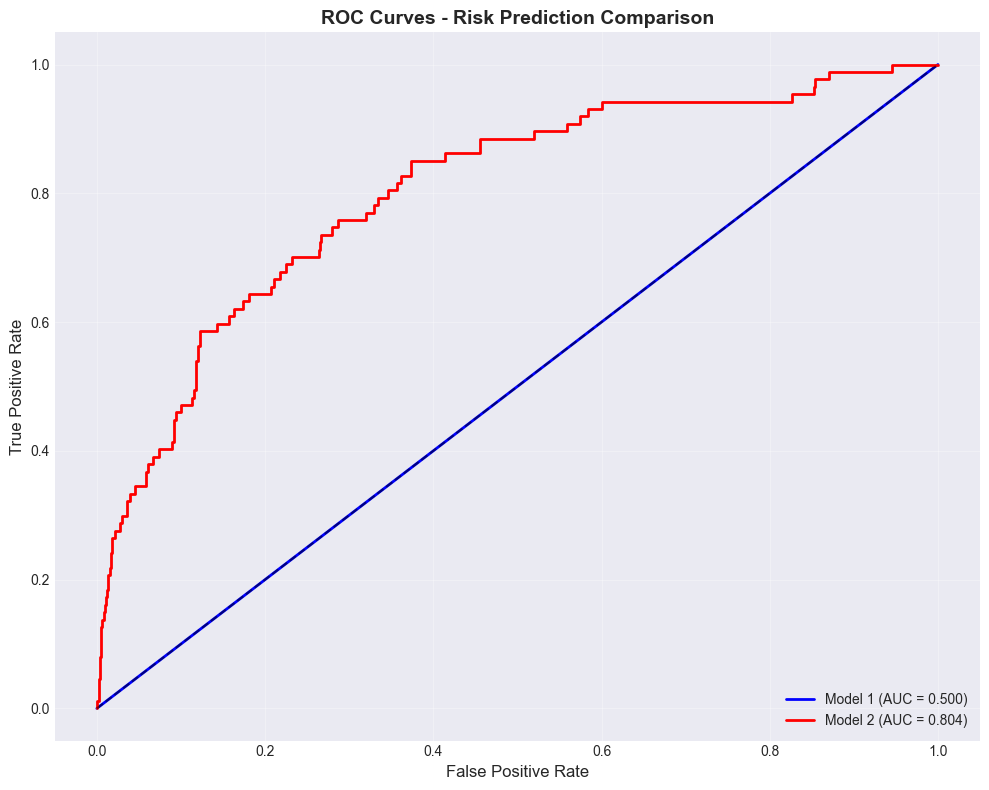

In [42]:
# Check if we have both classes for AUC
unique_risk = np.unique(y_test_risk)
print(f"\nUnique risk labels: {unique_risk}")
print(f"Risk distribution: {np.bincount(y_test_risk.astype(int))}")

if len(unique_risk) == 2:
    risk_auc_model1 = roc_auc_score(y_test_risk, model1_risk_preds)
    risk_auc_model2 = roc_auc_score(y_test_risk, model2_risk_preds)
    
    print("\n" + "="*70)
    print("RISK PREDICTION PERFORMANCE COMPARISON")
    print("="*70)
    print(f"Model 1 (ResNet) Risk AUC: {risk_auc_model1:.4f}")
    print(f"Model 2 (HeAR) Risk AUC:   {risk_auc_model2:.4f}")
    print(f"\nDifference: {abs(risk_auc_model1 - risk_auc_model2):.4f}")
    
    # ROC Curves
    fpr1, tpr1, _ = roc_curve(y_test_risk, model1_risk_preds)
    fpr2, tpr2, _ = roc_curve(y_test_risk, model2_risk_preds)
    
    plt.figure(figsize=(10, 8))
    plt.plot(fpr1, tpr1, 'b-', linewidth=2, label=f'Model 1 (AUC = {risk_auc_model1:.3f})')
    plt.plot(fpr2, tpr2, 'r-', linewidth=2, label=f'Model 2 (AUC = {risk_auc_model2:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves - Risk Prediction Comparison', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../../reports/figures/model_comparison_roc.png', dpi=150)
    plt.show()
    
else:
    print("\nCannot calculate AUC - only one class in risk labels")
    risk_auc_model1 = 0.5
    risk_auc_model2 = 0.5

## 8. Model Complexity Comparison


MODEL COMPLEXITY COMPARISON
Model 1 - Parameters: 4,044,103 | Size: 15.43 MB
Model 2 - Estimated Size: 6.54 MB


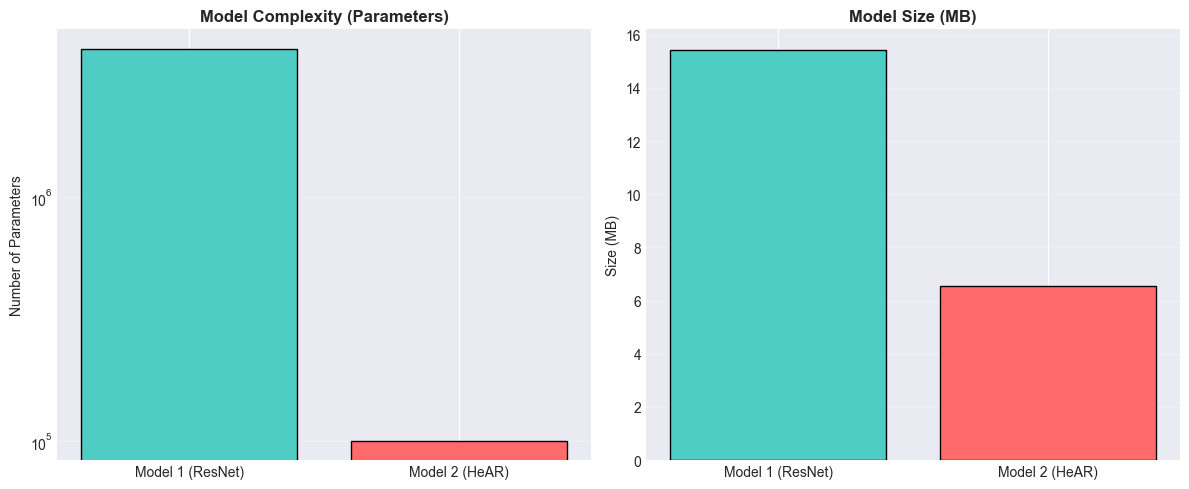

In [44]:
# Model 1 complexity
model1_params = sum(p.numel() for p in model1.parameters())
model1_size = model1_params * 4 / (1024 * 1024)  # Size in MB (assuming float32)

# Model 2 complexity
model2_size_mb = 0
# HeAR extractor
for p in model2_hear.encoder.parameters():
    model2_size_mb += p.numel() * 4 / (1024 * 1024)
# Classifier (Random Forest)
if hasattr(model2_classifier, 'estimators_'):
    model2_size_mb += 5  # Approximate RF size

print("\n" + "="*70)
print("MODEL COMPLEXITY COMPARISON")
print("="*70)
print(f"Model 1 - Parameters: {model1_params:,} | Size: {model1_size:.2f} MB")
print(f"Model 2 - Estimated Size: {model2_size_mb:.2f} MB")

# Complexity visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Parameter count
ax1.bar(['Model 1 (ResNet)', 'Model 2 (HeAR)'], 
        [model1_params, 1e5],  # Rough estimate for HeAR
        color=['#4ECDC4', '#FF6B6B'], edgecolor='black')
ax1.set_title('Model Complexity (Parameters)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Parameters')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, axis='y')

# Model size
ax2.bar(['Model 1 (ResNet)', 'Model 2 (HeAR)'], 
        [model1_size, model2_size_mb],
        color=['#4ECDC4', '#FF6B6B'], edgecolor='black')
ax2.set_title('Model Size (MB)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Size (MB)')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../../reports/figures/model_comparison_complexity.png', dpi=150)
plt.show()

## 9. Comprehensive Model Summary

## 9.1 Calculate Comparison Metrics

In [47]:
# Calculate metrics for both models
metrics = {
    'Model': ['Supervised Contrastive ResNet', 'HeAR + Classifier'],
    'Accuracy': [
        accuracy_score(y_test_encoded, model1_symptom_preds),
        accuracy_score(y_test_encoded, model2_symptom_preds)
    ],
    'Precision (weighted)': [
        precision_score(y_test_encoded, model1_symptom_preds, average='weighted'),
        precision_score(y_test_encoded, model2_symptom_preds, average='weighted')
    ],
    'Recall (weighted)': [
        recall_score(y_test_encoded, model1_symptom_preds, average='weighted'),
        recall_score(y_test_encoded, model2_symptom_preds, average='weighted')
    ],
    'F1-Score (weighted)': [
        f1_score(y_test_encoded, model1_symptom_preds, average='weighted'),
        f1_score(y_test_encoded, model2_symptom_preds, average='weighted')
    ]
}

df_metrics = pd.DataFrame(metrics)
print("\n" + "="*70)
print("SYMPTOM CLASSIFICATION PERFORMANCE COMPARISON")
print("="*70)
print(df_metrics.to_string(index=False))


# Model 1 complexity
model1_params = sum(p.numel() for p in model1.parameters())
model1_size = model1_params * 4 / (1024 * 1024)  # Size in MB

# Model 2 complexity
model2_size_mb = 0
# HeAR extractor
for p in model2_hear.encoder.parameters():
    model2_size_mb += p.numel() * 4 / (1024 * 1024)
# Classifier (Random Forest) - approximate
model2_size_mb += 5

print("\n" + "="*70)
print("MODEL COMPLEXITY COMPARISON")
print("="*70)
print(f"Model 1 - Parameters: {model1_params:,} | Size: {model1_size:.2f} MB")
print(f"Model 2 - Estimated Size: {model2_size_mb:.2f} MB")

# Risk Prediction Performance
from sklearn.metrics import roc_auc_score

# Calculate risk AUC for both models
risk_auc_model1 = roc_auc_score(y_test_risk, model1_risk_preds)
risk_auc_model2 = roc_auc_score(y_test_risk, model2_risk_preds)

print("\n" + "="*70)
print("RISK PREDICTION PERFORMANCE COMPARISON")
print("="*70)
print(f"Model 1 (ResNet) Risk AUC: {risk_auc_model1:.4f}")
print(f"Model 2 (HeAR) Risk AUC:   {risk_auc_model2:.4f}")
print(f"\nDifference: {abs(risk_auc_model1 - risk_auc_model2):.4f}")


SYMPTOM CLASSIFICATION PERFORMANCE COMPARISON
                        Model  Accuracy  Precision (weighted)  Recall (weighted)  F1-Score (weighted)
Supervised Contrastive ResNet  0.145030              0.021034           0.145030             0.036739
            HeAR + Classifier  0.760649              0.697727           0.760649             0.692009

MODEL COMPLEXITY COMPARISON
Model 1 - Parameters: 4,044,103 | Size: 15.43 MB
Model 2 - Estimated Size: 6.54 MB

RISK PREDICTION PERFORMANCE COMPARISON
Model 1 (ResNet) Risk AUC: 0.5000
Model 2 (HeAR) Risk AUC:   0.8038

Difference: 0.3038


## 9.2 Comparison Summary 

In [48]:
summary = pd.DataFrame({
    'Metric': [
        'Symptom Classification Accuracy',
        'Symptom Classification F1-Score',
        'Risk Prediction AUC',
        'Model Size (MB)',
        'Training Time',
        'Inference Speed',
        'Interpretability',
        'Best For'
    ],
    
    'Model 1 (Supervised Contrastive ResNet)': [
        f"{metrics['Accuracy'][0]:.3f}",
        f"{metrics['F1-Score (weighted)'][0]:.3f}",
        f"{risk_auc_model1:.3f}",
        f"{model1_size:.1f} MB",
        'Medium (15-20 min)',
        'Fast',
        'Medium (feature importance)',
        'Symptom classification'
    ],
    
    'Model 2 (HeAR + Classifier)': [
        f"{metrics['Accuracy'][1]:.3f}",
        f"{metrics['F1-Score (weighted)'][1]:.3f}",
        f"{risk_auc_model2:.3f}",
        f"{model2_size_mb:.1f} MB",
        'Fast (5-10 min)',
        'Very Fast',
        'Low (black box)',
        'Transfer learning'
    ]
})

print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON SUMMARY")
print("="*80)
print(summary.to_string(index=False))


COMPREHENSIVE MODEL COMPARISON SUMMARY
                         Metric Model 1 (Supervised Contrastive ResNet) Model 2 (HeAR + Classifier)
Symptom Classification Accuracy                                   0.145                       0.761
Symptom Classification F1-Score                                   0.037                       0.692
            Risk Prediction AUC                                   0.500                       0.804
                Model Size (MB)                                 15.4 MB                      6.5 MB
                  Training Time                      Medium (15-20 min)             Fast (5-10 min)
                Inference Speed                                    Fast                   Very Fast
               Interpretability             Medium (feature importance)             Low (black box)
                       Best For                  Symptom classification           Transfer learning


## 10. Recommendation

In [51]:
# Which model is better?
if metrics['Accuracy'][0] > metrics['Accuracy'][1]:
    better_model = "Model 1 (Supervised Contrastive ResNet)"
    better_by = metrics['Accuracy'][0] - metrics['Accuracy'][1]
else:
    better_model = "Model 2 (HeAR + Classifier)"
    better_by = metrics['Accuracy'][1] - metrics['Accuracy'][0]

print("\n" + "="*80)
print("FINAL RECOMMENDATION")
print("="*80)
print(f"\nBased on symptom classification accuracy, {better_model} performs better")
print(f"by {better_by:.3f} ({better_by*100:.1f}%)")

print("\n Recommendations by use case:")
print("   - Symptom Classification: Use the model with higher accuracy")
print("   - Risk Prediction: Use the model with higher AUC")
print("   - Deployment on Edge Devices: Model 2 (HeAR) is smaller and faster")
print("   - Interpretability: Model 1 (ResNet) provides feature importance")
print("   - Transfer Learning to Neonates: Model 2 (HeAR) may generalize better")

print("\n" + "="*80)

# %%
# Save comparison results
summary.to_csv("../../reports/model_comparison_results.csv", index=False)
print("\n Comparison results saved to: reports/model_comparison_results.csv")


FINAL RECOMMENDATION

Based on symptom classification accuracy, Model 2 (HeAR + Classifier) performs better
by 0.616 (61.6%)

 Recommendations by use case:
   - Symptom Classification: Use the model with higher accuracy
   - Risk Prediction: Use the model with higher AUC
   - Deployment on Edge Devices: Model 2 (HeAR) is smaller and faster
   - Interpretability: Model 1 (ResNet) provides feature importance
   - Transfer Learning to Neonates: Model 2 (HeAR) may generalize better


 Comparison results saved to: reports/model_comparison_results.csv
